# Street-form similarity

Each urban area in Geoff Boeing's published indicator table becomes one point. Indicators are standardized on all 10,351 areas, then reduced with principal components. Proximity is similarity of street statistics, not of the map drawing.

Cities already in the table use his numbers. A place that is not in the table is downloaded with OSMnx; see the last section before running that, because a few indicators cannot be reproduced and are filled with the world mean.

Data: [Global Urban Street Networks Indicators](https://doi.org/10.7910/DVN/ZTFPTB), OSMnx 2.0.2.

In [64]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

DATA = next(
    (
        path
        for path in (
            Path("data/indicators.csv"),
            Path("notebooks/data/indicators.csv"),
        )
        if path.exists()
    ),
    Path("notebooks/data/indicators.csv"),
)
if not DATA.exists():
    import urllib.request

    DATA.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(
        "https://dataverse.harvard.edu/api/access/datafile/11058506?format=original",
        DATA,
    )

raw = pd.read_csv(DATA)
raw.shape

(10351, 39)

## Indicators

Fourteen scale-free measures. Counts, totals, population, and area are left out so a larger city is not automatically far from a smaller one. `straightness` is left out because it is the reciprocal of `circuity`. Absolute elevation is left out; `grade_mean` keeps the slope of the streets. `bc_max` and `pagerank_max` are single-node extremes.

`prop_3way`, `prop_4way`, and `prop_deadend` do not sum to 1, because some junctions have five or more streets.

In [65]:
frame = raw.copy()
frame["intersect_density_km"] = frame["intersect_count_clean_topo"] / frame["area_km2"]
frame["street_density_km"] = frame["length_total"] / frame["area_km2"]

FEATURES = [
    "circuity",
    "orientation_entropy",
    "prop_4way",
    "prop_3way",
    "prop_deadend",
    "self_loop_proportion",
    "k_avg",
    "length_mean",
    "length_median",
    "bc_gini",
    "cc_avg_undir",
    "grade_mean",
    "intersect_density_km",
    "street_density_km",
]

work = frame.dropna(subset=FEATURES).reset_index(drop=True)
scaler = StandardScaler().fit(work[FEATURES])
Z = scaler.transform(work[FEATURES])
pca = PCA(n_components=2).fit(Z)
XY = pca.transform(Z)
work["pc1"] = XY[:, 0]
work["pc2"] = XY[:, 1]

variance = pd.Series(pca.explained_variance_ratio_, index=["PC1", "PC2"])
loadings = pd.DataFrame(pca.components_.T, index=FEATURES, columns=["PC1", "PC2"])
print(variance.map(lambda v: f"{v:.1%}"))
print(f"together {variance.sum():.1%}")
loadings.round(2).sort_values("PC1")

PC1    28.1%
PC2    26.4%
dtype: str
together 54.5%


,PC1,PC2
prop_deadend,-0.42,0.11
length_mean,-0.32,-0.30
circuity,-0.30,0.17
length_median,-0.27,-0.30
bc_gini,-0.10,0.37
orientation_entropy,-0.09,0.35
self_loop_proportion,-0.04,0.11
cc_avg_undir,-0.01,0.02
prop_3way,0.00,0.37
grade_mean,0.08,0.28


In [66]:
def _key(name: str) -> str:
    return str(name).strip().casefold().replace(" ", "_").replace("-", "_")


def find_city(name: str, country: str | None = None) -> pd.Series:
    named = work[work["core_city"].notna()]
    hits = named[named["core_city"].map(_key) == _key(name)]
    if country:
        hits = hits[hits["country_iso"].str.upper() == country.upper()]
    if hits.empty:
        raise LookupError(f"{name!r} is not in the indicator table. Use add_place.")
    if len(hits) > 1 and not country:
        preview = hits.sort_values("resident_pop", ascending=False)[
            ["core_city", "country_iso", "resident_pop"]
        ]
        raise LookupError("Several matches. Pass country_iso.\n" + preview.to_string(index=False))
    return hits.sort_values("resident_pop", ascending=False).iloc[0]


def nearest(row: pd.Series, k: int = 5) -> pd.DataFrame:
    vector = scaler.transform(pd.DataFrame([row[FEATURES]], columns=FEATURES))[0]
    distance = np.linalg.norm(Z - vector, axis=1)
    order = np.argsort(distance)
    picked = []
    for index in order:
        other = work.iloc[index]
        if other["uc_id"] == row.get("uc_id"):
            continue
        picked.append(index)
        if len(picked) == k:
            break
    out = work.iloc[picked][["core_city", "country_iso", "pc1", "pc2"]].copy()
    out.insert(2, "distance", distance[picked])
    return out.reset_index(drop=True)


def plot_plane(selected: pd.Series, neighbors: pd.DataFrame, title: str) -> None:
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(work["pc1"], work["pc2"], s=4, c="0.75", linewidths=0, label="10,351 urban areas")
    ax.scatter(neighbors["pc1"], neighbors["pc2"], s=28, c="C0", label="nearest in 14 dimensions")
    for _, item in neighbors.iterrows():
        ax.annotate(item["core_city"], (item["pc1"], item["pc2"]), textcoords="offset points", xytext=(4, 4), fontsize=8)
    ax.scatter([selected["pc1"]], [selected["pc2"]], s=80, c="C1", marker="*", label=selected["core_city"], zorder=3)
    ax.annotate(selected["core_city"], (selected["pc1"], selected["pc2"]), textcoords="offset points", xytext=(6, -8))
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(title)
    ax.legend(frameon=False)
    fig.tight_layout()


def show_city(name: str, country: str | None = None, k: int = 5) -> pd.DataFrame:
    selected = find_city(name, country)
    neighbors = nearest(selected, k)
    print(f"{selected['core_city']} ({selected['country_iso']})  PC1={selected['pc1']:.2f}  PC2={selected['pc2']:.2f}")
    plot_plane(selected, neighbors, "Street statistics, first two principal components")
    return neighbors


def _spread_labels(ax, points):
    offsets = [
        (0, 11), (0, -13), (12, 7), (-12, 7), (14, -8), (-14, -8),
        (18, 2), (-18, 2), (8, 14), (-8, -16),
    ]
    chosen = []
    for index, (x, y, label, color) in enumerate(points):
        best = offsets[index % len(offsets)]
        best_penalty = None
        for ox, oy in offsets:
            penalty = 0.0
            for px, py, pox, poy in chosen:
                if abs(x - px) < 0.45 and abs(y - py) < 0.45 and (ox, oy) == (pox, poy):
                    penalty += 5
                penalty += max(0.0, 0.35 - abs((x + ox / 80) - (px + pox / 80)))
                penalty += max(0.0, 0.28 - abs((y + oy / 80) - (py + poy / 80)))
            if best_penalty is None or penalty < best_penalty:
                best_penalty = penalty
                best = (ox, oy)
        chosen.append((x, y, best[0], best[1]))
        ax.annotate(
            label,
            (x, y),
            textcoords="offset points",
            xytext=best,
            fontsize=8,
            ha="center",
            va="center",
            color=color,
            annotation_clip=True,
        )


def show_cities(places: list[tuple[str, str]], labels: dict[tuple[str, str], str] | None = None, regions: dict[tuple[str, str], str] | None = None) -> pd.DataFrame:
    labels = labels or {}
    rows = []
    for name, country in places:
        row = find_city(name, country).copy()
        row["label"] = labels.get((name, country), name)
        row["region"] = (regions or {}).get((name, country), row["country_iso"])
        rows.append(row)
    chosen = pd.DataFrame(rows).reset_index(drop=True)
    vectors = scaler.transform(chosen[FEATURES])
    full = np.linalg.norm(vectors[:, None, :] - vectors[None, :, :], axis=2)
    nearest_rows = []
    for index, label in enumerate(chosen["label"]):
        order = np.argsort(full[index])
        other = int(order[1])
        nearest_rows.append(
            {
                "city": label,
                "pc1": chosen.loc[index, "pc1"],
                "pc2": chosen.loc[index, "pc2"],
                "nearest": chosen.loc[other, "label"],
                "distance": full[index, other],
            }
        )
    summary = pd.DataFrame(nearest_rows).sort_values("distance")

    fig, ax = plt.subplots(figsize=(11, 8), dpi=110)
    ax.scatter(work["pc1"], work["pc2"], s=4, c="0.82", linewidths=0, label="10,351 urban areas", zorder=0)
    palette = ["C0", "C1", "C2", "C3", "C4", "C5", "C6", "C8", "C9"]
    region_color = {}
    for region in chosen["region"]:
        if region not in region_color:
            region_color[region] = palette[len(region_color) % len(palette)]
    seen = set()
    for _, item in chosen.iterrows():
        color = region_color[item["region"]]
        ax.scatter(
            [item["pc1"]],
            [item["pc2"]],
            s=42,
            c=color,
            zorder=3,
            label=None if item["region"] in seen else item["region"],
        )
        seen.add(item["region"])
    _spread_labels(
        ax,
        [
            (item.pc1, item.pc2, item.label, region_color[item.region])
            for item in chosen.itertuples()
        ],
    )
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title("Street statistics, first two principal components")
    ax.legend(frameon=False, loc="best")
    fig.subplots_adjust(left=0.08, right=0.98, bottom=0.08, top=0.93)
    return summary.round(2)


## Cities on one plane

Two or three cities stand in for each large region. Color is the region, not the country. The table is the nearest other selected city in the original 14 standardized indicators.


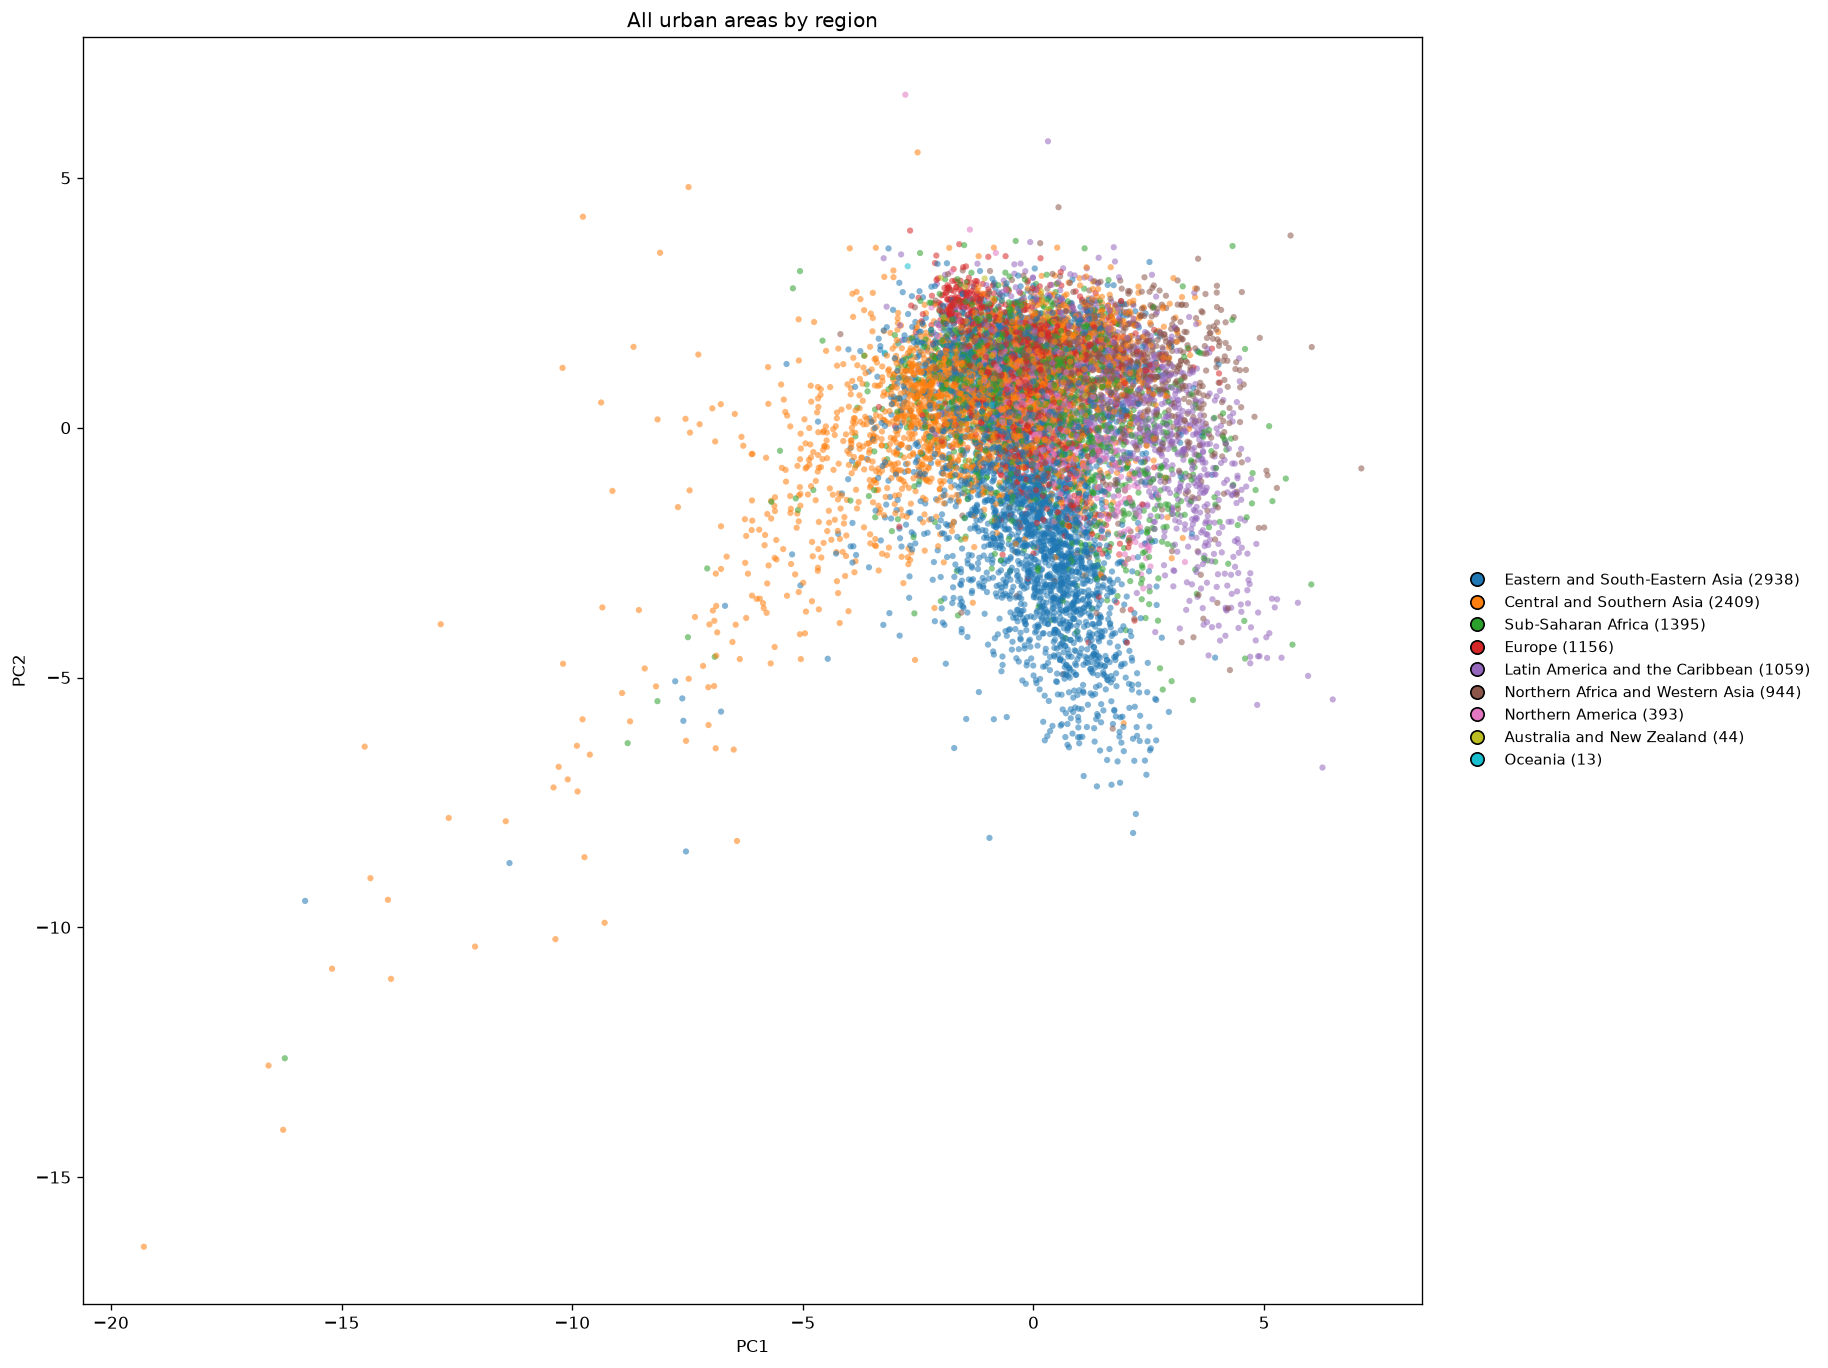

In [67]:
region_color = {
    "Eastern and South-Eastern Asia": "C0",
    "Central and Southern Asia": "C1",
    "Sub-Saharan Africa": "C2",
    "Europe": "C3",
    "Latin America and the Caribbean": "C4",
    "Northern Africa and Western Asia": "C5",
    "Northern America": "C6",
    "Australia and New Zealand": "C8",
    "Oceania": "C9",
}

order = np.random.default_rng(0).permutation(len(work))
shuffled = work.iloc[order]
fig, ax = plt.subplots(figsize=(18, 12), dpi=120)
ax.scatter(
    shuffled["pc1"],
    shuffled["pc2"],
    s=14,
    c=shuffled["world_region"].map(region_color),
    linewidths=0,
    alpha=0.55,
    rasterized=True,
)
handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor=color,
        markersize=8,
        label=f"{region} ({int((work['world_region'] == region).sum())})",
    )
    for region, color in region_color.items()
]
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("All urban areas by region")
ax.legend(handles=handles, loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=9)
fig.subplots_adjust(left=0.06, right=0.68, bottom=0.06, top=0.94)


## A place that is not in the table

Set `PLACE` to an OpenStreetMap query such as `"Delft, Netherlands"`, then run the cell. OSMnx downloads the drivable street network inside that place.

Reproduced from the download: circuity, orientation entropy, junction proportions, undirected degree, segment lengths, self-loops, intersection density, street density. Betweenness inequality (`bc_gini`), undirected clustering, and mean grade are filled with the world mean, so those three dimensions do not move the point. Intersection density here is OSMnx's intersection count per km², not Boeing's topologically cleaned count, so a downloaded place is not on exactly the same definition as the gray cloud.

In [68]:
PLACE = None  # example: "Delft, Netherlands"


def measure_place(query: str) -> pd.Series:
    import osmnx as ox

    boundary = ox.geocode_to_gdf(query)
    projected = boundary.to_crs(boundary.estimate_utm_crs())
    area_m2 = float(projected.geometry.area.sum())
    graph = ox.graph_from_place(query, network_type="drive")
    undirected = ox.convert.to_undirected(graph)
    stats = ox.stats.basic_stats(graph, area=area_m2)
    proportions = stats["streets_per_node_proportions"]
    lengths = [data["length"] for _, _, data in undirected.edges(data=True) if "length" in data]
    with_bearings = ox.bearing.add_edge_bearings(undirected)
    values = {
        "circuity": stats["circuity_avg"],
        "orientation_entropy": ox.bearing.orientation_entropy(with_bearings, num_bins=36),
        "prop_4way": proportions.get(4, 0.0),
        "prop_3way": proportions.get(3, 0.0),
        "prop_deadend": proportions.get(1, 0.0),
        "self_loop_proportion": stats["self_loop_proportion"],
        "k_avg": float(np.mean([degree for _, degree in undirected.degree()])),
        "length_mean": stats["street_length_avg"],
        "length_median": float(np.median(lengths)),
        "intersect_density_km": stats["intersection_density_km"],
        "street_density_km": stats["street_density_km"],
    }
    filled = ["bc_gini", "cc_avg_undir", "grade_mean"]
    for name in filled:
        values[name] = float(work[name].mean())
    row = pd.Series(values)
    row["core_city"] = query
    row["country_iso"] = ""
    row["uc_id"] = None
    print("Filled with the world mean, so they do not move the point:", ", ".join(filled))
    return row


def add_place(query: str, k: int = 5) -> pd.DataFrame:
    selected = measure_place(query)
    vector = scaler.transform(pd.DataFrame([selected[FEATURES]], columns=FEATURES))
    selected["pc1"], selected["pc2"] = pca.transform(vector)[0]
    neighbors = nearest(selected, k)
    print(f"{query}  PC1={selected['pc1']:.2f}  PC2={selected['pc2']:.2f}")
    plot_plane(selected, neighbors, query)
    return neighbors


if PLACE:
    add_place(PLACE)
